In [2]:
import subprocess
subprocess.run([
    r"c:/Users/sritv/AppData/Local/Programs/Python/Python313/python.exe",
    "-m", "pip", "install", "lightgbm", "catboost"
], check=True)

CompletedProcess(args=['c:/Users/sritv/AppData/Local/Programs/Python/Python313/python.exe', '-m', 'pip', 'install', 'lightgbm', 'catboost'], returncode=0)

In [4]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

In [5]:
df = pd.read_csv("cleaned_crop_data.csv")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()


Shape: (19295, 10)

Columns: ['Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Production', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield']


,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238333
3,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.420909
4,Dry chillies,1997,Whole Year,Assam,13587.0,9073,2051.4,1293074.79,4211.97,0.643636


In [6]:
# Define categorical columns for CatBoost
cat_cols = ['Crop', 'Season', 'State']

# Features and target
X = df.drop(columns=['Crop_Year', 'Production', 'Yield'])
y = df['Yield']

# For RF, XGBoost, LightGBM — they need numbers, so we one-hot encode
X_encoded = pd.get_dummies(X, columns=cat_cols)

# For CatBoost — it accepts raw strings, so we keep original X
# (we'll use X directly for CatBoost later)

# Split both versions with same random state (so comparison is fair)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)
X_train_cat, X_test_cat, _, _ = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Features (encoded):", X_train.shape[1])

Training samples: 15436
Testing samples: 3859
Features (encoded): 95


In [7]:
results = []

# ── Model 1: Random Forest ──
print("Training Random Forest...")
start = time.time()
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
t = time.time() - start
rf_pred = rf.predict(X_test)
results.append({"Model": "Random Forest",
                "R²": round(r2_score(y_test, rf_pred), 4),
                "RMSE": round(np.sqrt(mean_squared_error(y_test, rf_pred)), 4),
                "Time (s)": round(t, 2)})
print(f"  Done in {round(t,2)}s — R²: {results[-1]['R²']}")

# ── Model 2: XGBoost ──
print("Training XGBoost...")
start = time.time()
xgb = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4,
                   random_state=42, verbosity=0)
xgb.fit(X_train, y_train)
t = time.time() - start
xgb_pred = xgb.predict(X_test)
results.append({"Model": "XGBoost",
                "R²": round(r2_score(y_test, xgb_pred), 4),
                "RMSE": round(np.sqrt(mean_squared_error(y_test, xgb_pred)), 4),
                "Time (s)": round(t, 2)})
print(f"  Done in {round(t,2)}s — R²: {results[-1]['R²']}")

# ── Model 3: LightGBM ──
print("Training LightGBM...")
start = time.time()
lgbm = LGBMRegressor(n_estimators=200, learning_rate=0.05, random_state=42)
lgbm.fit(X_train, y_train)
t = time.time() - start
lgbm_pred = lgbm.predict(X_test)
results.append({"Model": "LightGBM",
                "R²": round(r2_score(y_test, lgbm_pred), 4),
                "RMSE": round(np.sqrt(mean_squared_error(y_test, lgbm_pred)), 4),
                "Time (s)": round(t, 2)})
print(f"  Done in {round(t,2)}s — R²: {results[-1]['R²']}")

# ── Model 4: CatBoost ──
print("Training CatBoost...")
start = time.time()
cat_features_idx = [X_train_cat.columns.get_loc(c) for c in cat_cols]
cb = CatBoostRegressor(iterations=200, learning_rate=0.05, depth=6,
                       random_seed=42, verbose=0)
cb.fit(X_train_cat, y_train, cat_features=cat_features_idx)
t = time.time() - start
cb_pred = cb.predict(X_test_cat)
results.append({"Model": "CatBoost",
                "R²": round(r2_score(y_test, cb_pred), 4),
                "RMSE": round(np.sqrt(mean_squared_error(y_test, cb_pred)), 4),
                "Time (s)": round(t, 2)})
print(f"  Done in {round(t,2)}s — R²: {results[-1]['R²']}")

# ── Comparison Table ──
print("\n========== MODEL COMPARISON ==========")
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

Training Random Forest...
  Done in 2.93s — R²: 0.9558
Training XGBoost...
  Done in 0.36s — R²: 0.9249
Training LightGBM...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001033 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1195
[LightGBM] [Info] Number of data points in the train set: 15436, number of used features: 93
[LightGBM] [Info] Start training from score 4.187852
  Done in 2.05s — R²: 0.9051
Training CatBoost...
  Done in 5.8s — R²: 0.8842

========== MODEL COMPARISON ==========
        Model     R²   RMSE  Time (s)
Random Forest 0.9558 2.1952      2.93
      XGBoost 0.9249 2.8621      0.36
     LightGBM 0.9051 3.2174      2.05
     CatBoost 0.8842 3.5547      5.80


In [8]:
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold, cross_val_score

print("Tuning CatBoost — this may take 3-5 minutes...")

cb_tuned = CatBoostRegressor(
    iterations=1000,          # more trees
    learning_rate=0.03,       # slower but better learning
    depth=8,                  # deeper trees
    l2_leaf_reg=3,            # regularization to prevent overfitting
    bagging_temperature=0.5,  # randomness like RF's bootstrap
    random_strength=0.5,      # more robustness
    random_seed=42,
    verbose=0
)

start = time.time()
cb_tuned.fit(X_train_cat, y_train, cat_features=cat_features_idx)
t = time.time() - start

cb_tuned_pred = cb_tuned.predict(X_test_cat)
r2 = round(r2_score(y_test, cb_tuned_pred), 4)
rmse = round(np.sqrt(mean_squared_error(y_test, cb_tuned_pred)), 4)

print(f"\nTuned CatBoost Results:")
print(f"  R²   : {r2}")
print(f"  RMSE : {rmse}")
print(f"  Time : {round(t, 2)}s")
print(f"\nRandom Forest was: R²=0.9558, RMSE=2.1952")
print(f"CatBoost is now  : R²={r2}, RMSE={rmse}")

Tuning CatBoost — this may take 3-5 minutes...

Tuned CatBoost Results:
  R²   : 0.9365
  RMSE : 2.6334
  Time : 37.46s

Random Forest was: R²=0.9558, RMSE=2.1952
CatBoost is now  : R²=0.9365, RMSE=2.6334


In [9]:
from sklearn.model_selection import GridSearchCV, KFold

print("Tuning Random Forest — this may take 5-8 minutes...")

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    scoring='r2',
    cv=kf,
    verbose=1,
    n_jobs=-1
)

start = time.time()
rf_grid.fit(X_train, y_train)
t = time.time() - start

best_rf = rf_grid.best_estimator_
best_pred = best_rf.predict(X_test)

print(f"\nBest Parameters: {rf_grid.best_params_}")
print(f"Tuned RF R²  : {round(r2_score(y_test, best_pred), 4)}")
print(f"Tuned RF RMSE: {round(np.sqrt(mean_squared_error(y_test, best_pred)), 4)}")
print(f"Default RF R²: 0.9558")
print(f"Time: {round(t,2)}s")

Tuning Random Forest — this may take 5-8 minutes...
Fitting 5 folds for each of 72 candidates, totalling 360 fits

Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Tuned RF R²  : 0.9517
Tuned RF RMSE: 2.2956
Default RF R²: 0.9558
Time: 243.81s


C:\Users\sritv\AppData\Local\Temp\ipykernel_26916\2263300089.py:60: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sritv\AppData\Local\Temp\ipykernel_26916\2263300089.py:61: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight',
C:\Users\sritv\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


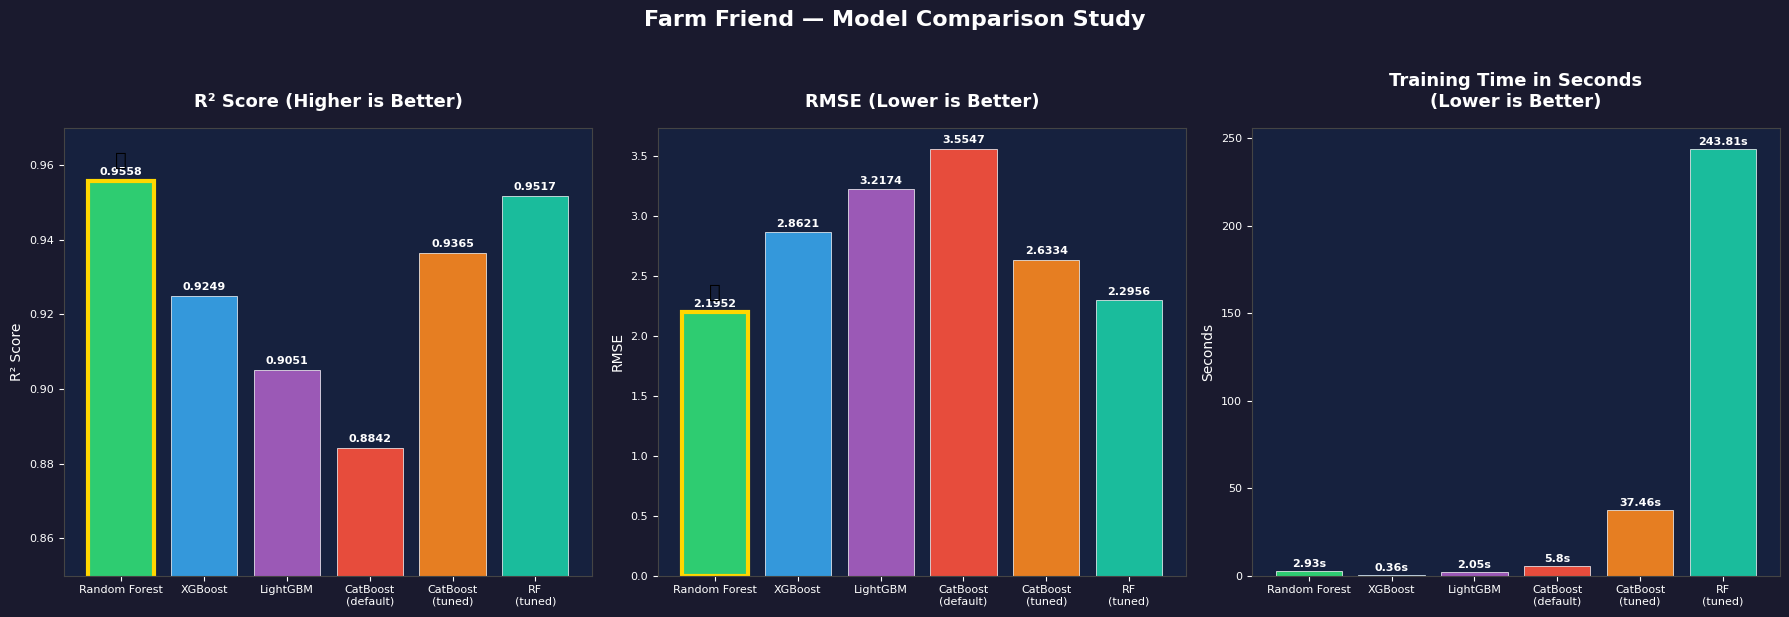

✅ Chart saved as model_comparison.png


In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Data ──
models = ['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost\n(default)', 'CatBoost\n(tuned)', 'RF\n(tuned)']
r2_scores = [0.9558, 0.9249, 0.9051, 0.8842, 0.9365, 0.9517]
rmse_scores = [2.1952, 2.8621, 3.2174, 3.5547, 2.6334, 2.2956]
times = [2.93, 0.36, 2.05, 5.80, 37.46, 243.81]
colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c', '#e67e22', '#1abc9c']
winner_idx = 0  # Random Forest

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#1a1a2e')
for ax in axes:
    ax.set_facecolor('#16213e')

# ── Chart 1: R² Scores ──
bars1 = axes[0].bar(models, r2_scores, color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('R² Score (Higher is Better)', color='white', fontsize=13, fontweight='bold', pad=15)
axes[0].set_ylim(0.85, 0.97)
axes[0].tick_params(colors='white', labelsize=8)
axes[0].set_ylabel('R² Score', color='white')
axes[0].spines[['top','right','left','bottom']].set_color('#444')
for bar, val in zip(bars1, r2_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 str(val), ha='center', va='bottom', color='white', fontsize=8, fontweight='bold')
# highlight winner
bars1[winner_idx].set_edgecolor('gold')
bars1[winner_idx].set_linewidth(3)
axes[0].text(winner_idx, r2_scores[winner_idx] + 0.004, '🏆', ha='center', fontsize=14)

# ── Chart 2: RMSE Scores ──
bars2 = axes[1].bar(models, rmse_scores, color=colors, edgecolor='white', linewidth=0.5)
axes[1].set_title('RMSE (Lower is Better)', color='white', fontsize=13, fontweight='bold', pad=15)
axes[1].tick_params(colors='white', labelsize=8)
axes[1].set_ylabel('RMSE', color='white')
axes[1].spines[['top','right','left','bottom']].set_color('#444')
for bar, val in zip(bars2, rmse_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                 str(val), ha='center', va='bottom', color='white', fontsize=8, fontweight='bold')
bars2[winner_idx].set_edgecolor('gold')
bars2[winner_idx].set_linewidth(3)
axes[1].text(winner_idx, rmse_scores[winner_idx] + 0.12, '🏆', ha='center', fontsize=14)

# ── Chart 3: Training Time ──
bars3 = axes[2].bar(models, times, color=colors, edgecolor='white', linewidth=0.5)
axes[2].set_title('Training Time in Seconds\n(Lower is Better)', color='white', fontsize=13, fontweight='bold', pad=15)
axes[2].tick_params(colors='white', labelsize=8)
axes[2].set_ylabel('Seconds', color='white')
axes[2].spines[['top','right','left','bottom']].set_color('#444')
for bar, val in zip(bars3, times):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val}s', ha='center', va='bottom', color='white', fontsize=8, fontweight='bold')

# ── Title ──
fig.suptitle('Farm Friend — Model Comparison Study', 
             color='white', fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight',
            facecolor='#1a1a2e', edgecolor='none')
plt.show()
print("✅ Chart saved as model_comparison.png")

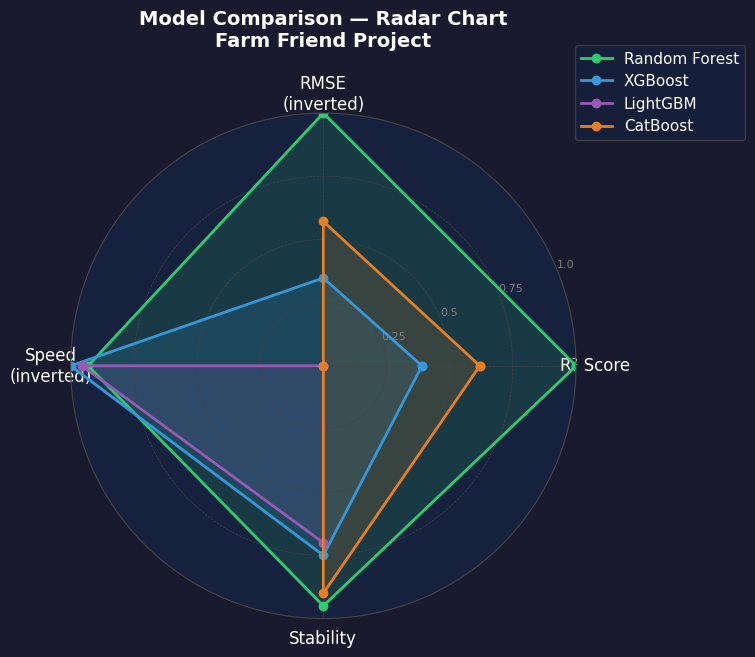

✅ Radar chart saved


In [11]:
from matplotlib.patches import FancyBboxPatch
import matplotlib.pyplot as plt
import numpy as np

# Normalize scores to 0-1 scale (higher = better for all)
# R² already 0-1, RMSE and Time we invert (lower is better → higher is better)
models_radar = ['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost']
metrics = ['R² Score', 'RMSE\n(inverted)', 'Speed\n(inverted)', 'Stability']

r2_vals =   [0.9558, 0.9249, 0.9051, 0.9365]
rmse_vals =  [2.1952, 2.8621, 3.2174, 2.6334]  
time_vals =  [2.93,   0.36,   2.05,   37.46]

# Normalize: invert RMSE and Time so higher = better
rmse_norm = [1 - (v - min(rmse_vals)) / (max(rmse_vals) - min(rmse_vals)) for v in rmse_vals]
time_norm  = [1 - (v - min(time_vals)) / (max(time_vals) - min(time_vals)) for v in time_vals]
r2_norm    = [(v - min(r2_vals))   / (max(r2_vals)   - min(r2_vals))   for v in r2_vals]
# Stability = inverse of overfitting risk (RF=high, XGB=med, LGBM=med, CB=high)
stability  = [0.95, 0.75, 0.70, 0.90]

# Combine
data = np.array([
    [r2_norm[i], rmse_norm[i], time_norm[i], stability[i]]
    for i in range(4)
])

categories = metrics
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

colors_r = ['#2ecc71', '#3498db', '#9b59b6', '#e67e22']

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#16213e')

for i, (model, color) in enumerate(zip(models_radar, colors_r)):
    values = data[i].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, color=color, label=model)
    ax.fill(angles, values, alpha=0.15, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, color='white', fontsize=12)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25', '0.5', '0.75', '1.0'], color='gray', fontsize=8)
ax.spines['polar'].set_color('#444')
ax.grid(color='#444', linestyle='--', linewidth=0.5)

ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15),
          facecolor='#16213e', edgecolor='#444',
          labelcolor='white', fontsize=11)

ax.set_title('Model Comparison — Radar Chart\nFarm Friend Project',
             color='white', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('radar_chart.png', dpi=150, bbox_inches='tight',
            facecolor='#1a1a2e', edgecolor='none')
plt.show()
print("✅ Radar chart saved")

In [12]:
import joblib

# Train on FULL data for best real-world performance
final_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
final_rf.fit(X_encoded, y)

# Save model AND column names (brain.py needs both)
joblib.dump(final_rf, "model.pkl")
joblib.dump(X_encoded.columns.tolist(), "feature_columns.pkl")

print("✅ model.pkl saved")
print("✅ feature_columns.pkl saved")
print(f"Features saved: {len(X_encoded.columns)}")

✅ model.pkl saved
✅ feature_columns.pkl saved
Features saved: 95
